# Worksheet 4 - Scientific Visualisation MVE080/MMG640
## Part 1: Uncertainty and storytelling with data

Names of all group members:

- Daniel Esteban Lahti
- Ana Camila Jimenez Mendoza
- Edin Ahmemulic
- Filip Keerberg

This is the first worksheet in the course *Scientific Visualisation*. This Jupyter notebook has three functions:

1. It describes the tasks.
2. It (sometimes) provides coding templates that you can use as a basis for your own code.
3. It is a template also for the report that you upload in Canvas.

The tasks are of various types: some are to read some text and then comment on it (no coding), and some are about creating visualisations using plotnine. Once you have finished all the tasks, export this document as an HTML file and upload it in Canvas. 

The goal of these homeworks is to learn how to improve your skills in visualising your science. You solve the homeworks in groups, however annotate all the code (even the theoretical parts) with who solved each question. **Eventhough the homework is submitted as a group you will be *individually* evaluated**. Motivate your choice of graph, legend, colourmap etc below your graph in a separate cell. 

Notice that Jupyter notebooks use [Markdown](https://docs.github.com/en/github/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax#links) for writing text cells. Make sure you understand the basics. 

Throughout the assignment you shall use a Python workflow.
If you are completely new to Python, take a look at [this page](pythonbasics.org).
Python can do essentially all that MATLAB can, plus more. 
In this course we shall use Python in different contexts, starting with the [Jupyter Notebook interface](https://jupyter-notebook.readthedocs.io/en/stable/notebook.html). 

Matrices and arrays are handled through the NumPy module. [Learn here](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html) how NumPy is different from MATLAB.

The below loads the packages required for this homework.

In [9]:
import numpy as np
import pandas as pd
import geopandas as gpd
from plotnine import *
# Currently in a plotine dependancy they have deprication warning, so 
# we mute warnings to have a better experience
import warnings
warnings.filterwarnings("ignore")

# A nice color palette for categorical data 
cbPalette = ["#E69F00", "#56B4E9", "#009E73", 
             "#F0E442", "#0072B2", "#D55E00", 
             "#CC79A7", "#999999"]

## Task 1

Read Chapter 16 of [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/), then answer the questions below.

### Question 1.1

During Lecture 6, we visualised uncertainty for point estimates using i) graded error bars and ii) fuzziness (slide 7). Briefly describe when each kind of visual is suitable.

### Answer 1.1
_Your answer here_

### Question 1.2

Another way to visualise uncertainty is a **Hypothetical outcome plots** (Chapter 16 in [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/)). Briefly describe the key features of such a visual.

### Answer 1.2
_Your answer here_

### Question 1.3

Often when doing regression (fitting a curve to data), we want to use the regression model to make predictions. What is important to think about when visualising model predictions?

### Answer 1.3
_Your answer here_


## Uncertainty  

For this part reading chapter 16 in [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/) can help.

### Question 2.1

Coffee is undoubtedly a popular beverage. On Canvas, I have uploaded a dataset with ratings for coffee beans from six different countries. 

Here, we are interested in identifying which country on average has the best quality beans. Create two plots, where in i) you plot the mean ($\mu$) and standard deviation for each country (using error bars), and ii) where you plot the mean and standard error of the mean estimate. Briefly discuss the drawbacks with error bars. 

As a reminder. For country $j$ with coffee ratings $x^{(j)}_1, \ldots, x^{(j)}_{n_j}$ the sample mean is given by 

$$
\hat{\mu}^{(j)} = \sum_{i = 1}^{n_j} x_i^{(j)},
$$

sample standard deviation by

$$
\hat{\sigma}^{(j)} = \sqrt{\frac{1}{n - 1} \sum_{i = 1}^{n_j} (x_i^{(j)} - \hat{\mu}^{(j)})^2},
$$

and sample standard error for $\hat{\mu}^{(j)}$

$$
\hat{\sigma}_{\hat{\mu}^{(j)}} = \frac{\hat{\sigma}^{(j)}}{\sqrt{n}}
$$

and a confidence interval with confidence level $1 - \alpha$ is given by;

$$
\hat{\mu}^{(j)} \pm t_{n-1}(1 - \alpha / 2) \hat{\sigma}_{\hat{\mu}^{(j)}}
$$

where $t_{n-1}$ is the t-distribution with $n-1$ degree of freedom. For confidence level $1 - \alpha=0.95$ and $n = 30$ we have that $t_{29}(1 - 0.025) \approx 2.05$.

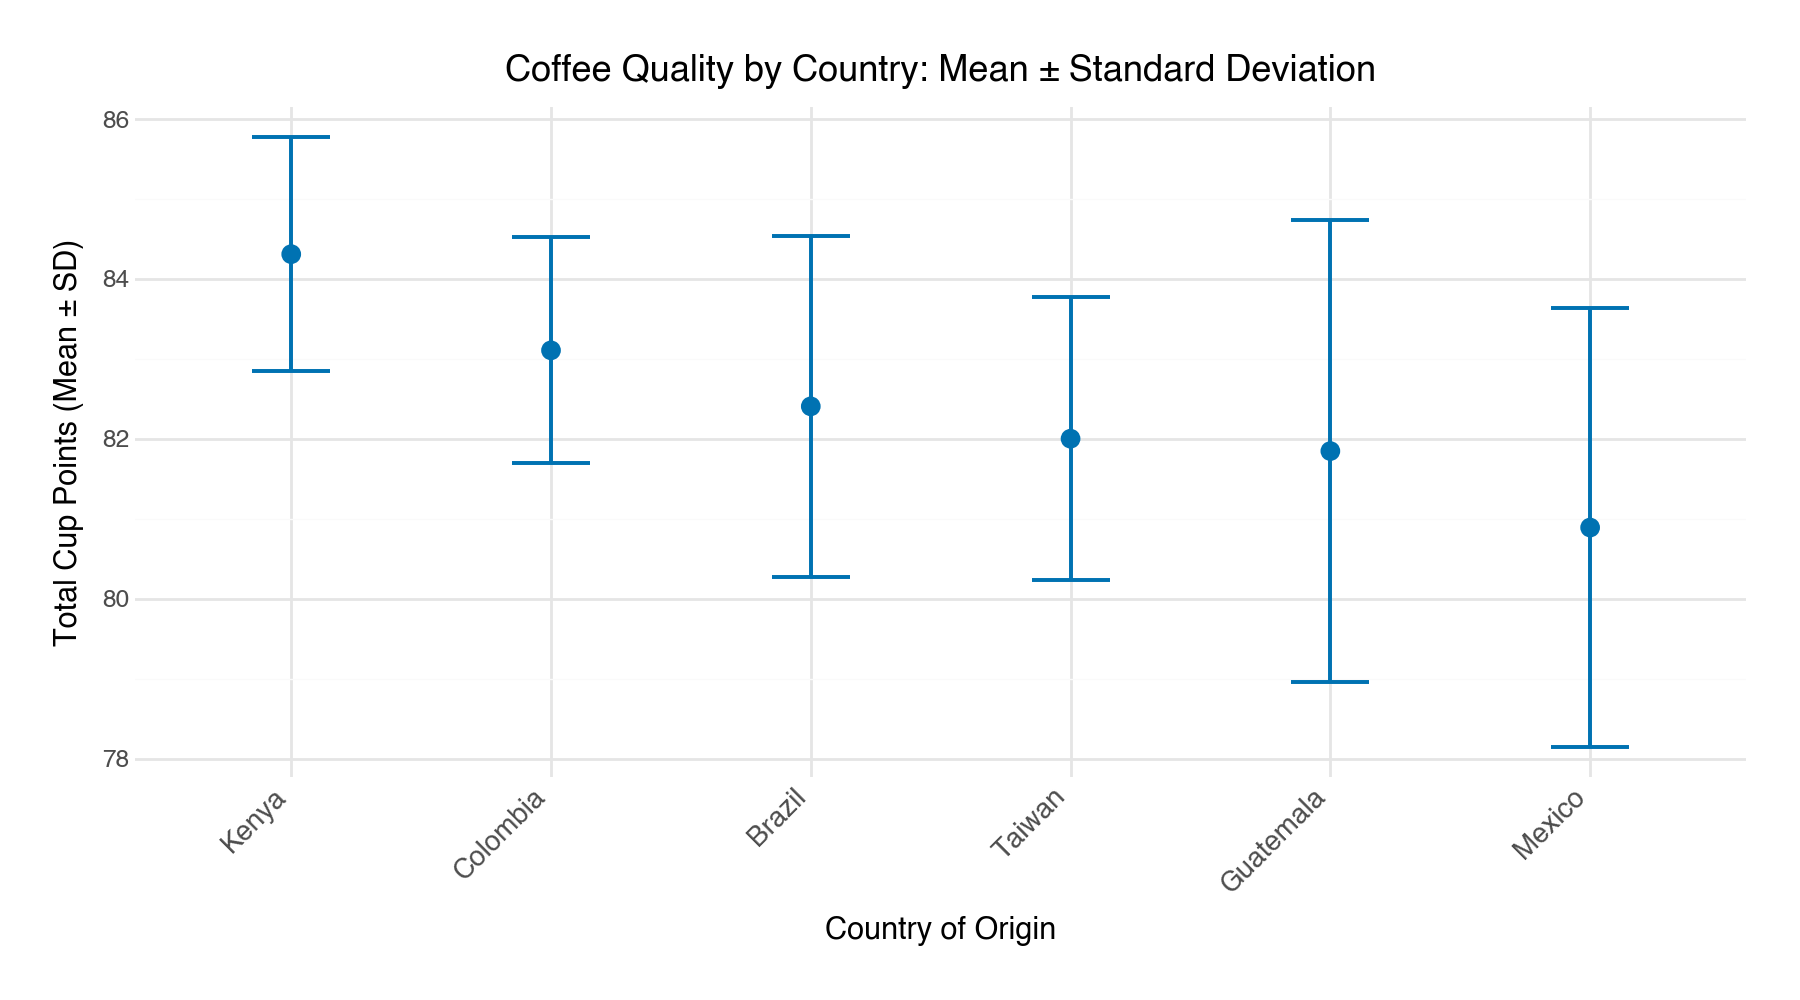

In [10]:
# Insert code here for visual 1
# Remember to print the visual 

coffee_data = pd.read_csv("Homework4_resources/part 1/q2.1.-q2.2. (coffee tidy)/Coffee_tidy.csv")

stats_by_country = coffee_data.groupby('country_of_origin').agg(
    mean_rating=('total_cup_points', 'mean'),
    std_dev=('total_cup_points', 'std'),
    n=('total_cup_points', 'count')
).reset_index()

stats_by_country = stats_by_country.sort_values('mean_rating', ascending=False)
stats_by_country['country_of_origin'] = pd.Categorical(
    stats_by_country['country_of_origin'],
    categories=stats_by_country['country_of_origin'],
    ordered=True
)

#visual_1 = 
(
    ggplot(stats_by_country, aes(x='country_of_origin', y='mean_rating'))
    + geom_point(size=3, color=cbPalette[4])
    + geom_errorbar(
        aes(ymin='mean_rating - std_dev', ymax='mean_rating + std_dev'),
        width=0.3,
        size=0.8,
        color=cbPalette[4]
    )
    + labs(
        title="Coffee Quality by Country: Mean ± Standard Deviation",
        x="Country of Origin",
        y="Total Cup Points (Mean ± SD)"
    )
    + theme_minimal()
    + theme(
        plot_title=element_text(size=13, face='bold'),
        axis_text_x=element_text(angle=45, hjust=1, size=10),
        plot_margin=0.03,
        figure_size=(9, 5)
    )
)

#print(visual_1)

In [11]:
from scipy import stats

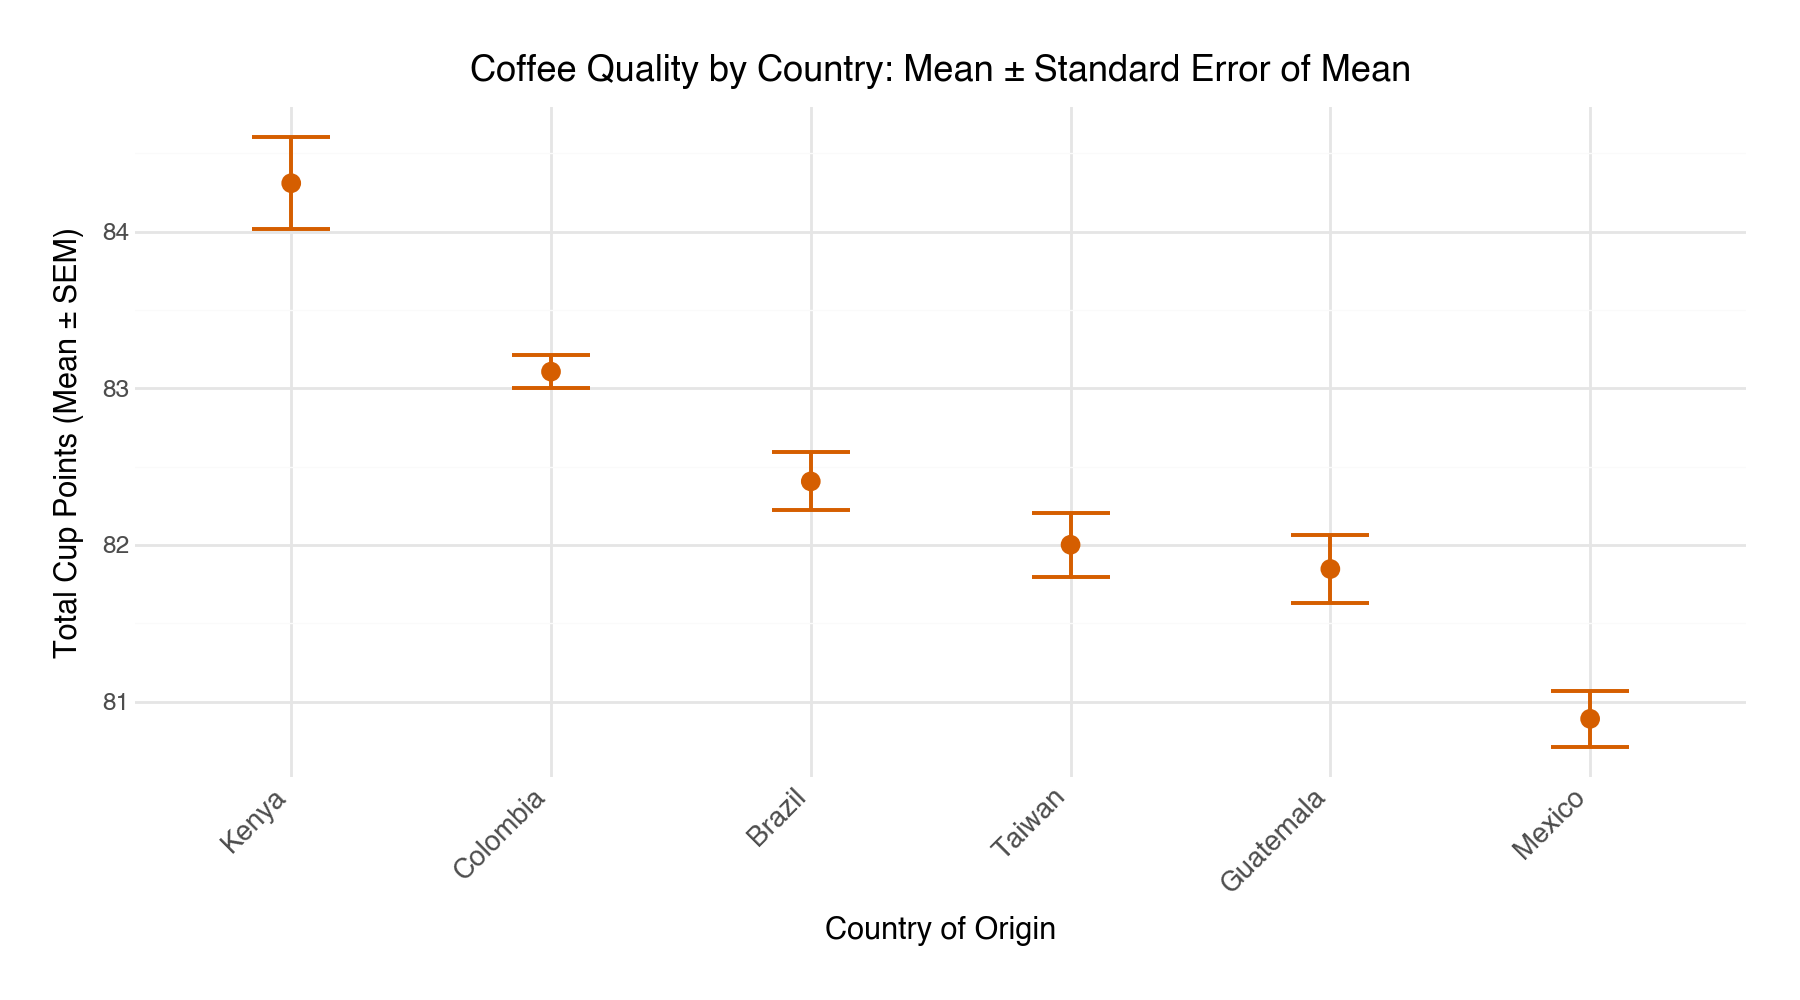

In [12]:
# Insert code here for visual 2
# Remember to print the visual 

stats_by_country['sem'] = stats_by_country['std_dev'] / np.sqrt(stats_by_country['n'])

confidence_level = 0.95
stats_by_country['ci_lower'] = stats_by_country.apply(
    lambda row: row['mean_rating'] - stats.t.ppf((1 + confidence_level) / 2, row['n'] - 1) * row['sem'],
    axis=1
)
stats_by_country['ci_upper'] = stats_by_country.apply(
    lambda row: row['mean_rating'] + stats.t.ppf((1 + confidence_level) / 2, row['n'] - 1) * row['sem'],
    axis=1
)

#visual_2 = 
(
    ggplot(stats_by_country, aes(x='country_of_origin', y='mean_rating'))
    + geom_point(size=3, color=cbPalette[5])
    + geom_errorbar(
        aes(ymin='mean_rating - sem', ymax='mean_rating + sem'),
        width=0.3,
        size=0.8,
        color=cbPalette[5]
    )
    + labs(
        title="Coffee Quality by Country: Mean ± Standard Error of Mean",
        x="Country of Origin",
        y="Total Cup Points (Mean ± SEM)"
    )
    + theme_minimal()
    + theme(
        plot_title=element_text(size=13, face='bold'),
        axis_text_x=element_text(angle=45, hjust=1, size=10),
        plot_margin=0.03,
        figure_size=(9, 5)
    )
)

#print(visual_2)

*Insert brief discussion*

Error bars are misleading for group comparisons. Standard deviation bars (plot 1) are too wide because they show data spread, not estimate precision. Standard error bars (plot 2) are tighter but overlapping bars don't clearly indicate whether differences are statistically meaningful. You really need confidence intervals or formal statistical tests to say definitively which countries produce better coffee.

### Question 2.2

Now using the coffee dataset, visualise the uncertainty in the mean estimate using i) graded error bars (here, plot confidence intervals with 80%, 90% and 99% confidence) and ii) fuzzy error bars (as on slide 7 in Lecture 6).

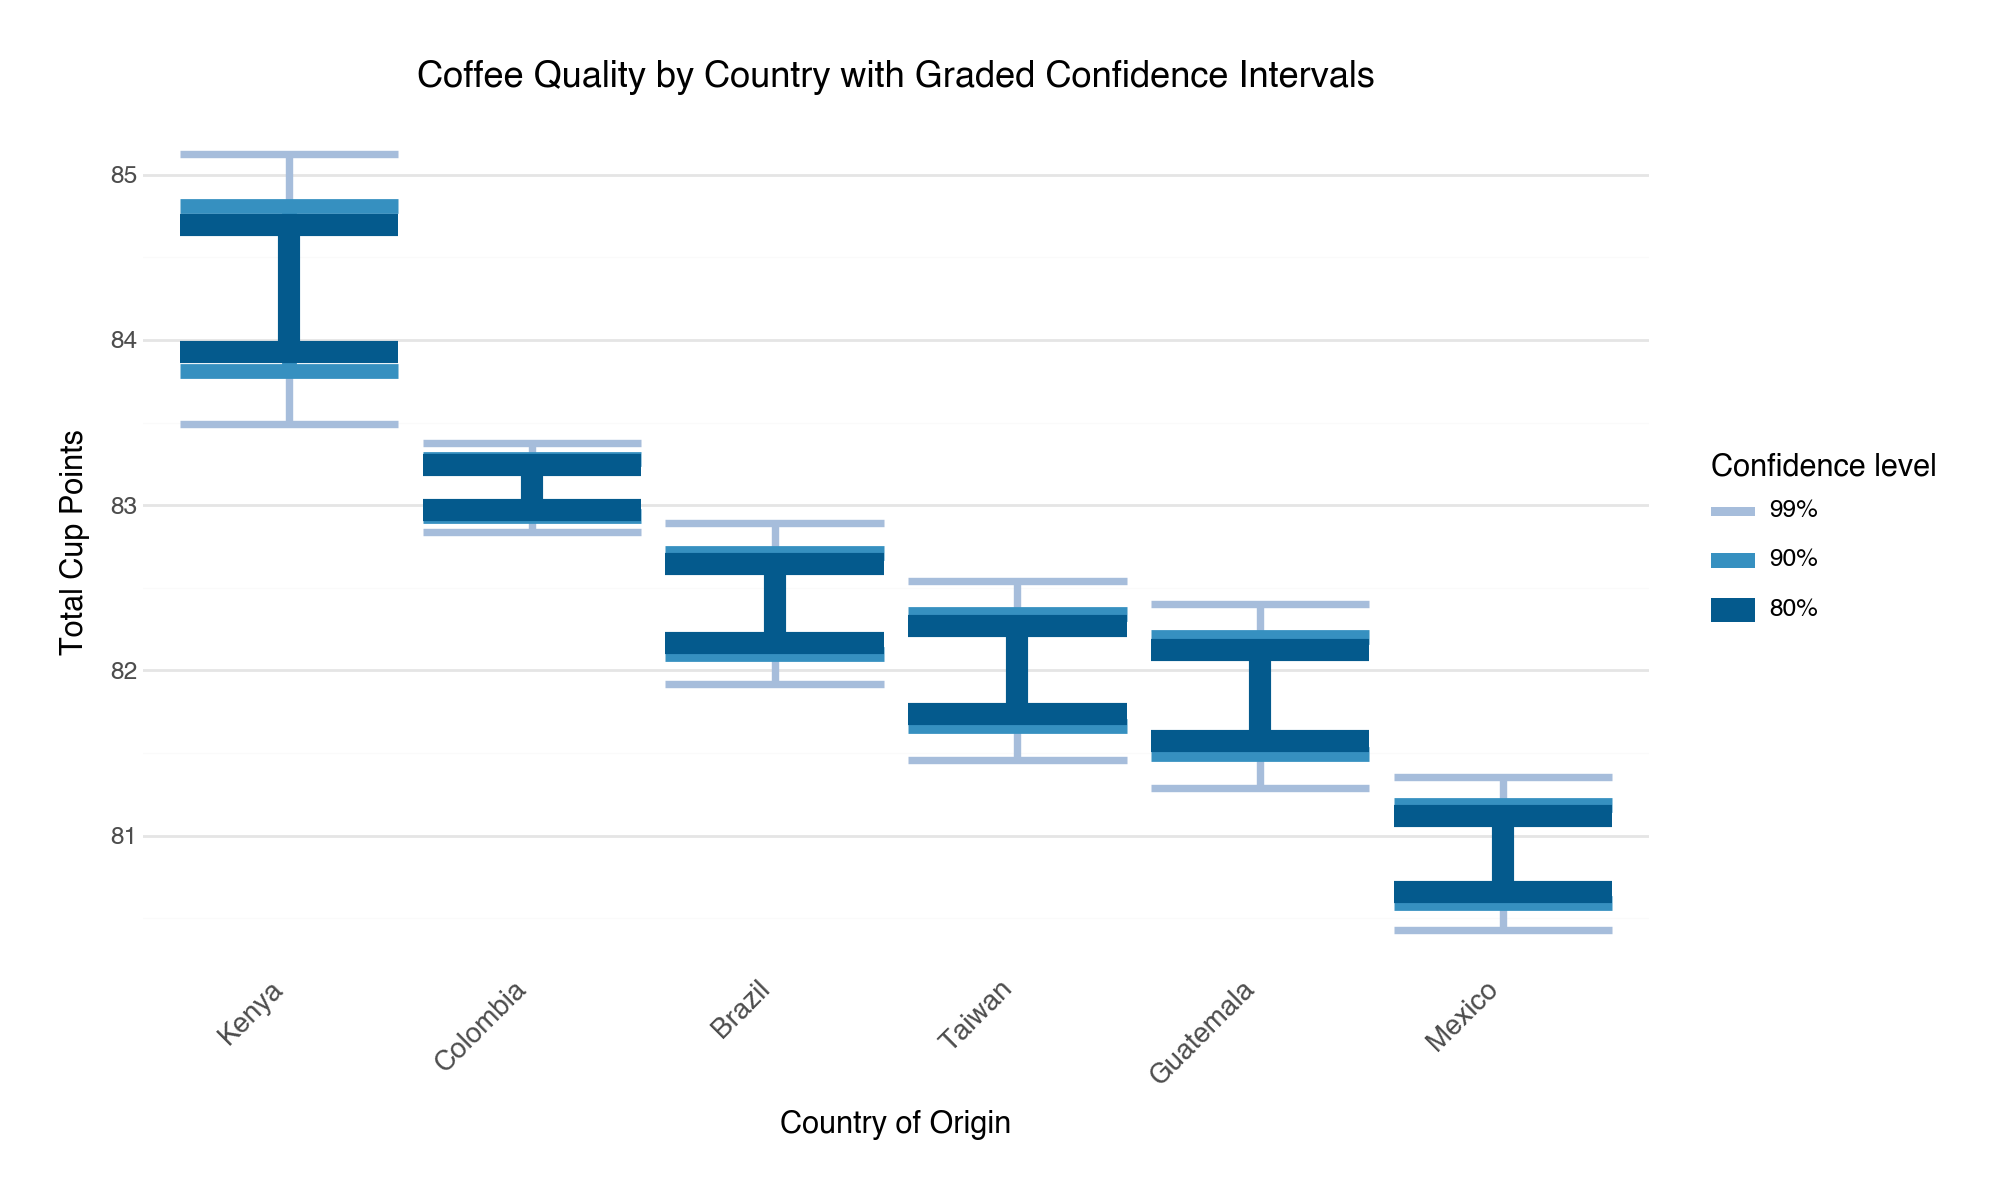

In [61]:
# Insert code here for visual 1
# Remember to print the visual

confidence_levels = [0.80, 0.90, 0.99]
stats_expanded = []

for conf_level in confidence_levels:
    stats_temp = stats_by_country.copy()
    stats_temp['confidence_level'] = f"{int(conf_level*100)}%"
    
    stats_temp['ci_lower'] = stats_temp.apply(
        lambda row: row['mean_rating'] - stats.t.ppf((1 + conf_level) / 2, row['n'] - 1) * row['sem'],
        axis=1
    )
    stats_temp['ci_upper'] = stats_temp.apply(
        lambda row: row['mean_rating'] + stats.t.ppf((1 + conf_level) / 2, row['n'] - 1) * row['sem'],
        axis=1
    )
    
    stats_expanded.append(stats_temp)

stats_graded = pd.concat(stats_expanded, ignore_index=True)

stats_graded['confidence_level'] = pd.Categorical(
    stats_graded['confidence_level'],
    categories=['99%', '90%', '80%'],
    ordered=True
)

#visual_1 = 
(
    ggplot(stats_graded, aes(x='country_of_origin'))
    + geom_errorbar(
        aes(ymin='ci_lower', ymax='ci_upper', color='confidence_level'),
        width=0.15
    )
    + geom_errorbar(
        aes(ymin='ci_lower', ymax='ci_upper', size='confidence_level', color='confidence_level'),
        width=0.0
    )
    + scale_color_manual(
        values=["#a6bddb", "#3690c0", "#045a8d"],
        name="Confidence level"
    )
    + scale_size_manual(
        values=[1.5, 3.0, 4.5],
        name="Confidence level"
    )
    + labs(
        title="Coffee Quality by Country with Graded Confidence Intervals",
        x="Country of Origin",
        y="Total Cup Points"
    )
    + theme_minimal()
    + theme(
        plot_title=element_text(size=13, face='bold'),
        axis_text_x=element_text(angle=45, hjust=1, size=10),
        panel_grid_major_x=element_blank(),
        plot_margin=0.03,
        figure_size=(10, 6)
    )
)

#print(visual_1)

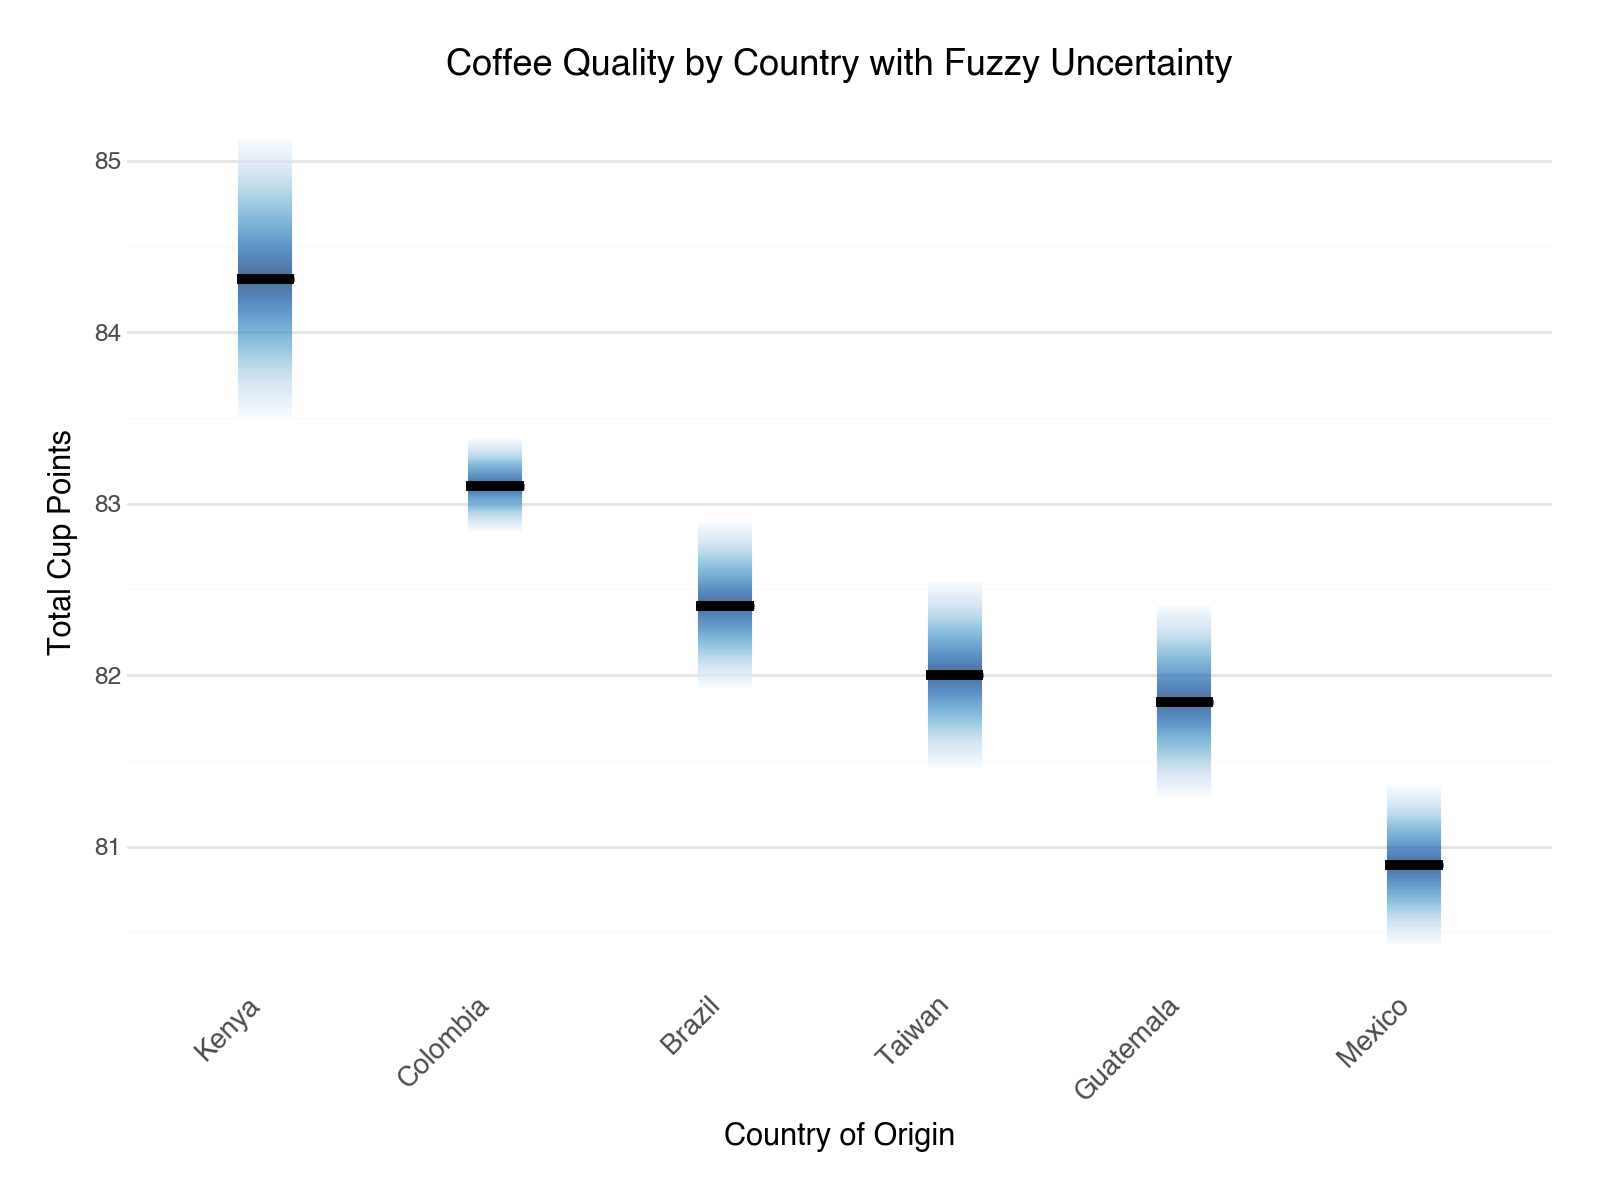

In [40]:
# Insert code here for visual 2
# Remember to print the visual 


# Visual 2: Fuzzy error bars (estilo slide 7 del lecture)
# Crear datos para el efecto "fuzzy"
stats_fuzzy_99 = stats_graded[stats_graded['confidence_level'] == '99%'].copy()

# Crear gradiente de líneas para efecto fuzzy
line_color = np.concatenate([np.linspace(0, 50, 50), np.linspace(50, 0, 50)])
data_fuzzy = pd.DataFrame()

for i in range(stats_fuzzy_99.shape[0]):
    val_min = stats_fuzzy_99.iloc[i]['ci_lower']
    val_max = stats_fuzzy_99.iloc[i]['ci_upper']
    mean_val = stats_fuzzy_99.iloc[i]['mean_rating']
    country = stats_fuzzy_99.iloc[i]['country_of_origin']
    
    df_tmp = pd.DataFrame({
        'val_line': np.linspace(val_min, val_max, 100),
        'color_line': line_color,
        'country_of_origin': country,
        'mean_rating': mean_val
    })
    
    data_fuzzy = pd.concat([data_fuzzy, df_tmp], ignore_index=True)

# Asegurar el orden categórico
data_fuzzy['country_of_origin'] = pd.Categorical(
    data_fuzzy['country_of_origin'],
    categories=stats_by_country['country_of_origin'].cat.categories,
    ordered=True
)

#visual_2 = 
(
    ggplot(data_fuzzy, aes(x='country_of_origin', y='val_line'))
    + geom_line(aes(color='color_line', group='country_of_origin'), size=11.0, alpha=0.7)
    + geom_crossbar(
        data=stats_by_country,
        mapping=aes(x='country_of_origin', y='mean_rating', ymin='mean_rating', ymax='mean_rating'),
        width=0.25,
        size=1.0,
        color='black'
    )
    + scale_color_cmap("Blues")
    + labs(
        title="Coffee Quality by Country with Fuzzy Uncertainty",
        x="Country of Origin",
        y="Total Cup Points"
    )
    + theme_minimal()
    + theme(
        plot_title=element_text(size=13, face='bold'),
        legend_position='none',
        panel_grid_major_x=element_blank(),
        axis_text_x=element_text(angle=45, hjust=1, size=10),
        plot_margin=0.03,
        figure_size=(8, 6)
    )
)

#print(visual_2)

### Question 2.3

Frequency graphs are a powerful tool for visualising probabilities. On Canvas, I have uploaded an image of such a graph. Recreate it (you do not have to recreate the colours perfectly). The figure might look strange when rendered in Jupyter (then, it is better to save it to disk and see how it looks like),

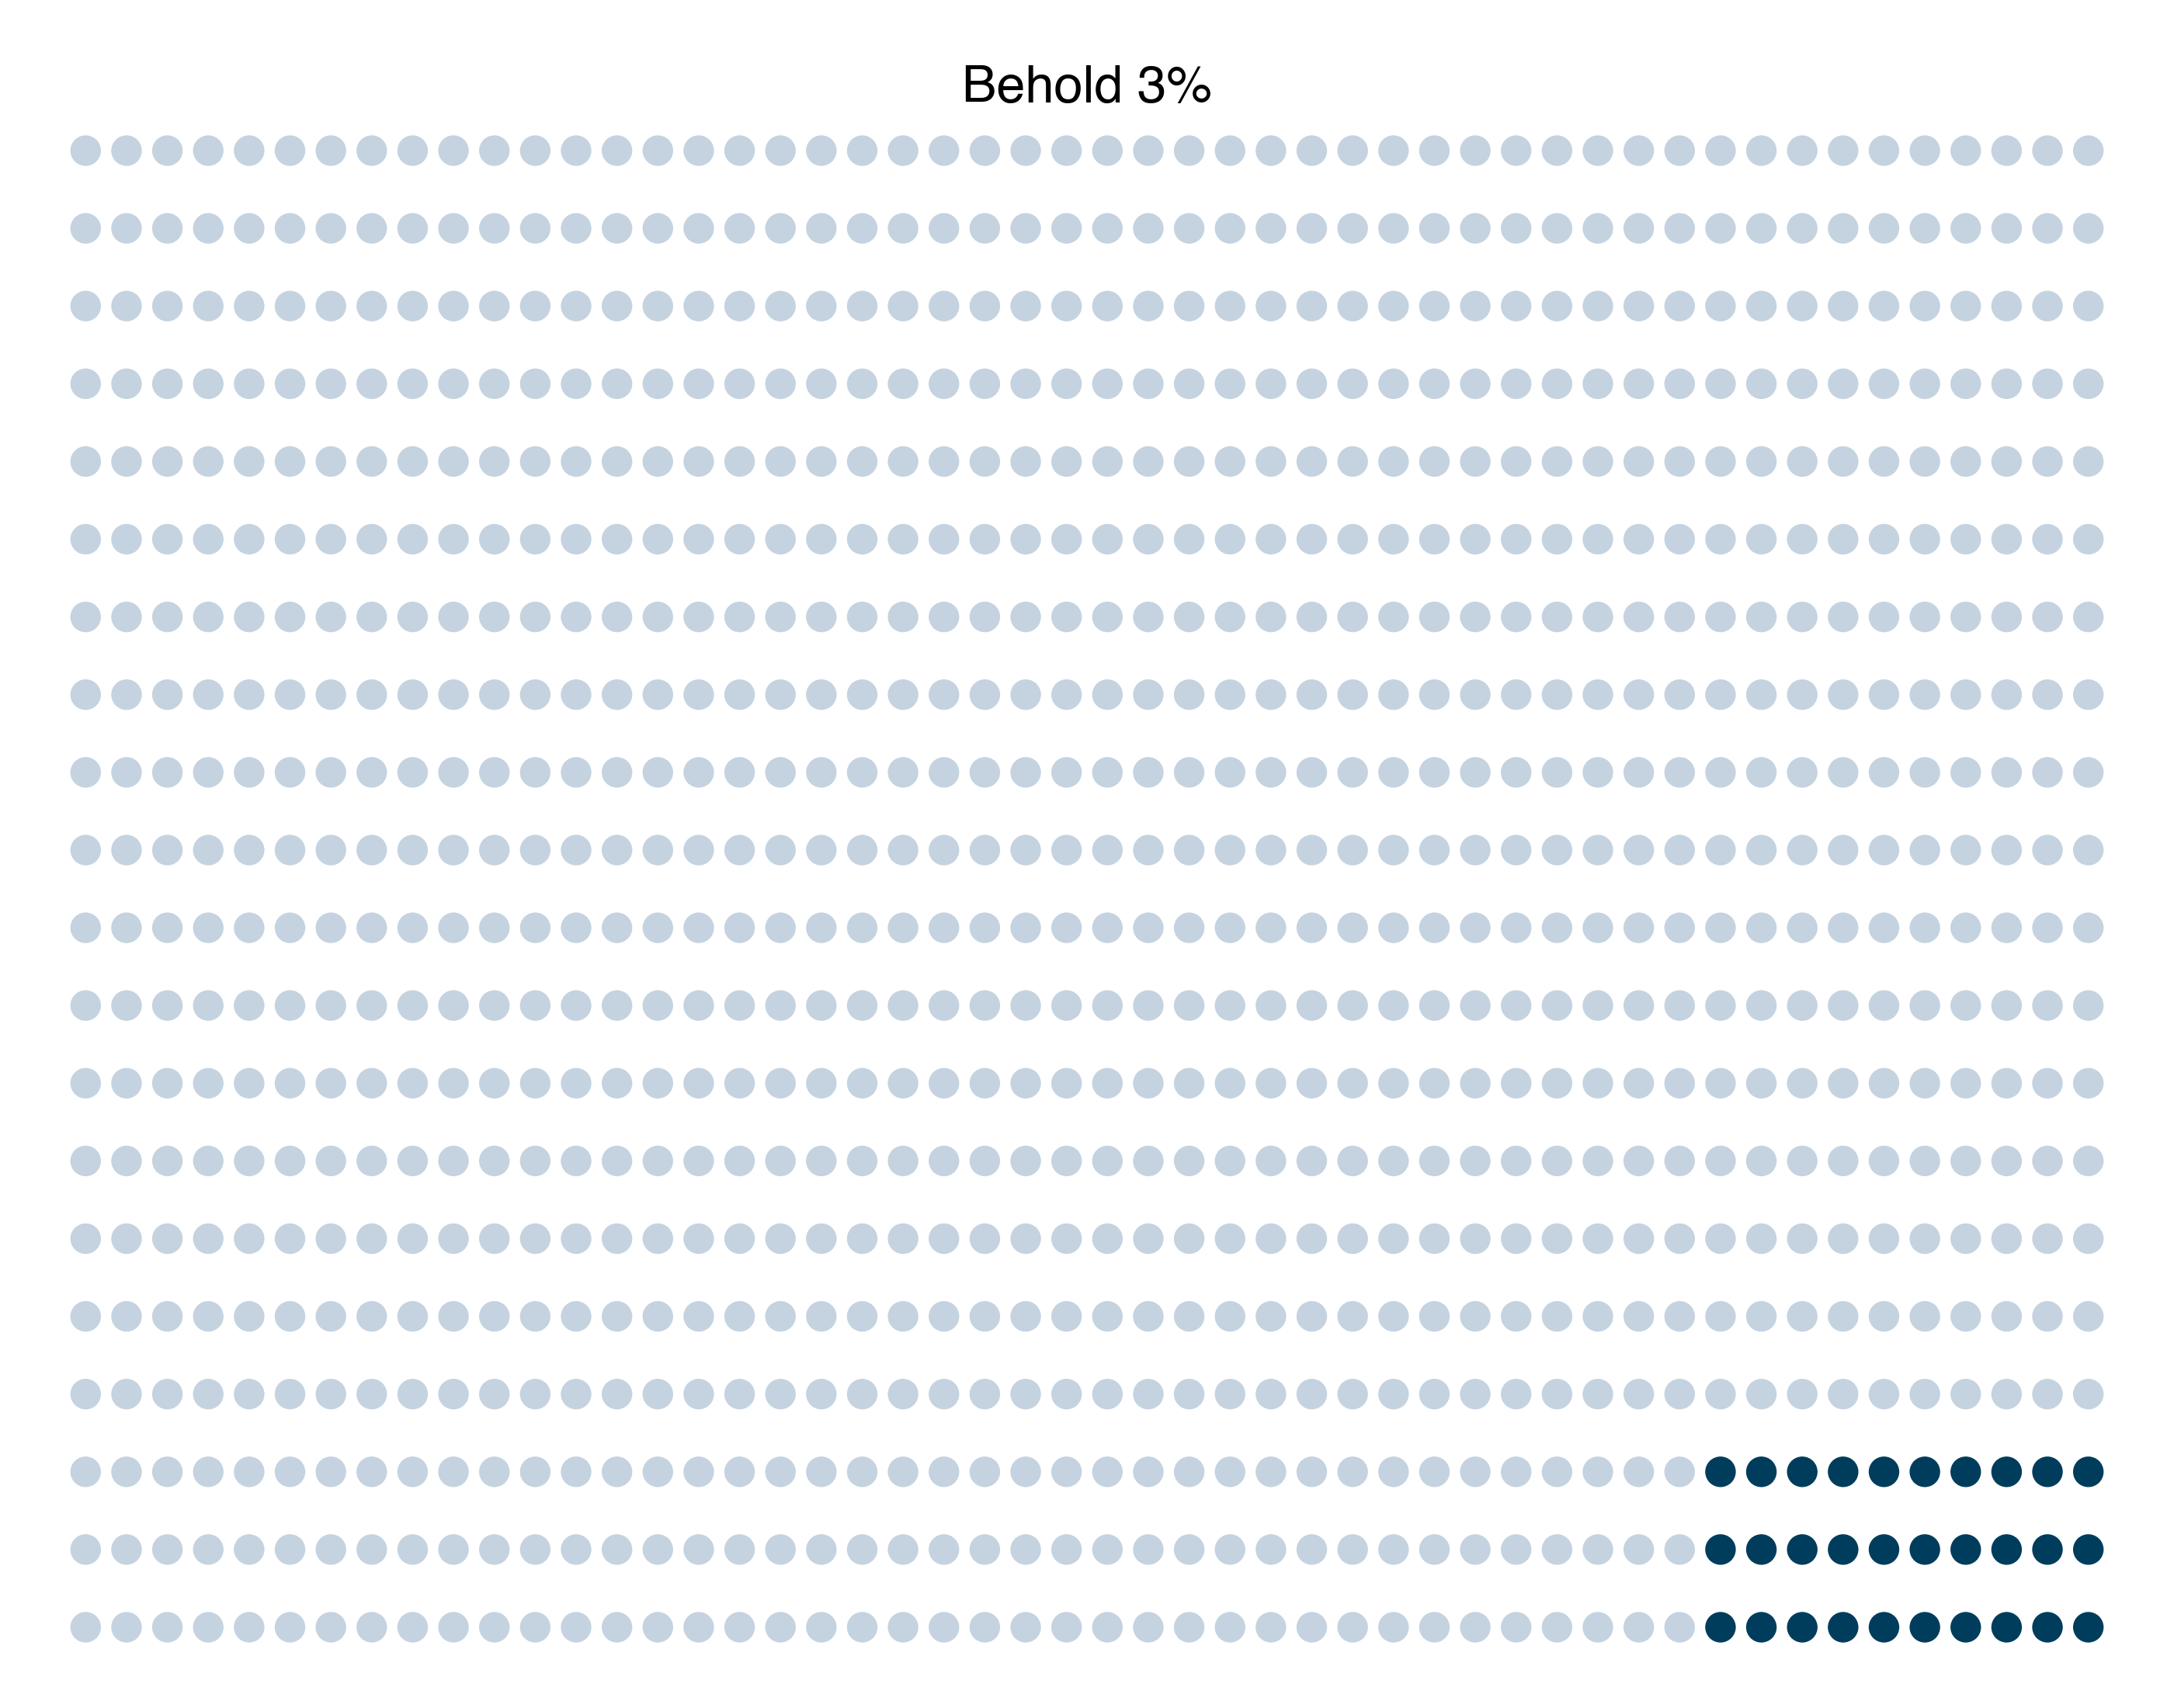

In [62]:
# Insert code here
# Remember to print the visual

n_cols = 50
n_rows = 20
total_dots = n_cols * n_rows

x_coords = []
y_coords = []
highlight = []

for row in range(n_rows):
    for col in range(n_cols):
        x_coords.append(col)
        y_coords.append(row)
        
        if row < 3 and col >= 40:
            highlight.append("Yes")
        else:
            highlight.append("No")

data_freq = pd.DataFrame({
    'x': x_coords,
    'y': y_coords,
    'highlight': highlight
})

color_map = {"No": "#C5D3E0", "Yes": "#003D5C"}

#visual = 
(
    ggplot(data_freq, aes(x='x', y='y', fill='highlight'))
    + geom_point(size=8, shape='o', stroke=0)
    + scale_fill_manual(values=color_map)
    + scale_x_continuous(expand=(0.01, 0.01))
    + scale_y_continuous(expand=(0.01, 0.01))
    + labs(title="Behold 3%")
    + theme_void()
    + theme(
        legend_position='none',
        plot_title=element_text(size=24, face='bold', ha='center'),
        plot_margin=0.03,
        figure_size=(14, 11),
        panel_background=element_rect(fill='white'),
        plot_background=element_rect(fill='white')
    )
)

#print(visual)

### Question 2.4

There are different ways to visualise curve fits. One is the fan plot (see lecture 6). On Canvas, I have uploaded a fan plot and associated dataset; use this dataset to recreate the visual.

**Note** - Hypothetical outcomes are generated via bootstraping, for computational speed it might be worthwhile to downsample the hypothetical outcomes.

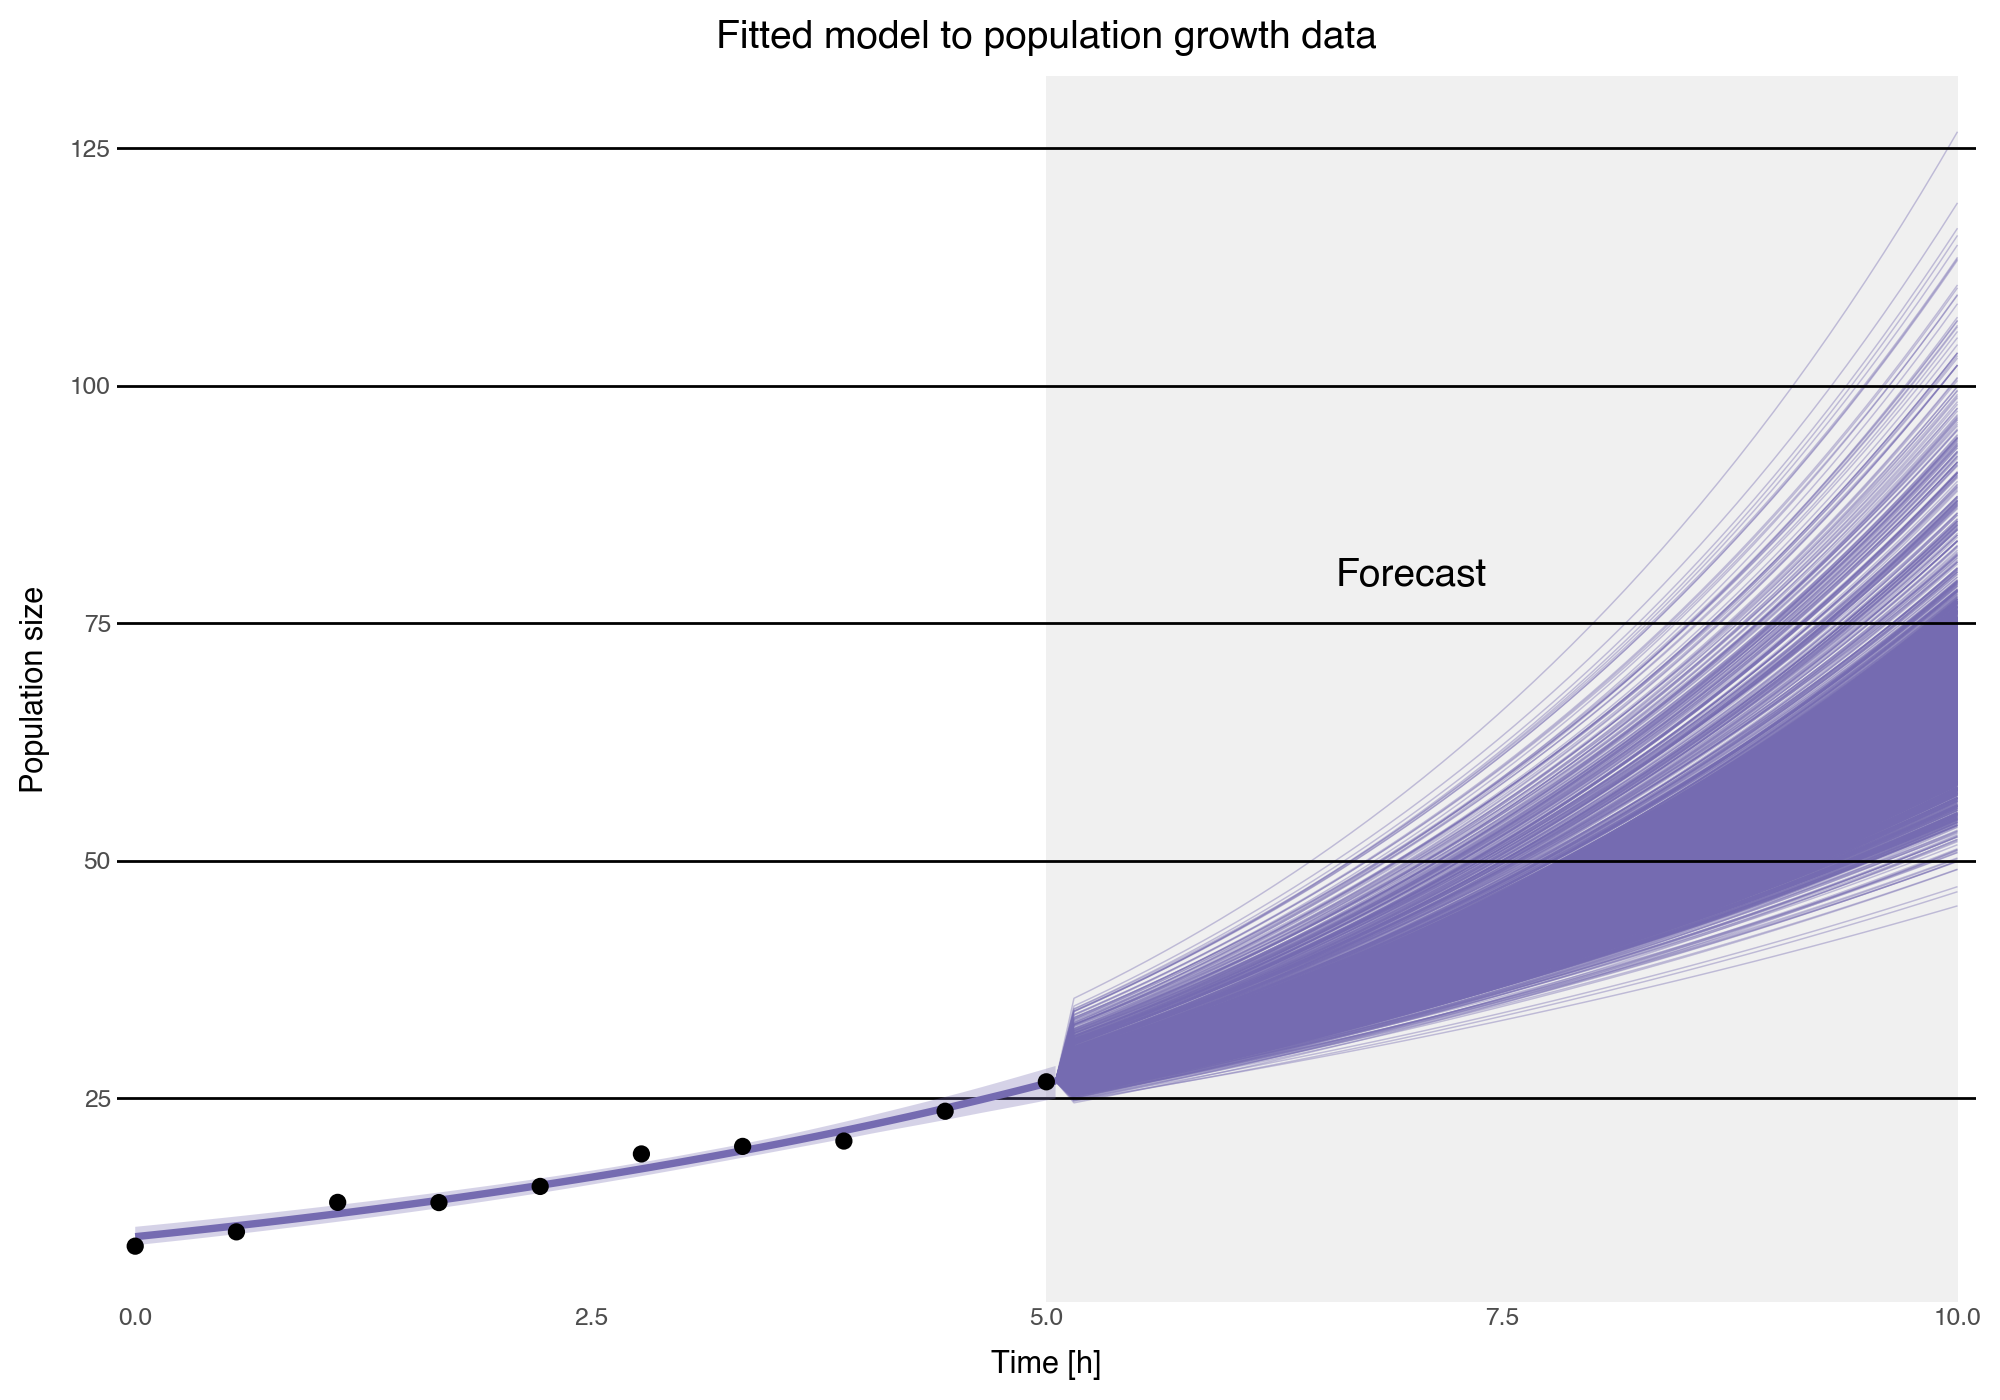

In [66]:
# Insert code here
# Remember to print the visual

data_obs = pd.read_csv("Homework4_resources/part 1/q2.4. (fan-plot)/datasets/Data_obs-1.csv")
fit_fan = pd.read_csv("Homework4_resources/part 1/q2.4. (fan-plot)/datasets/Fit_fan.csv")
pred_funnel = pd.read_csv("Homework4_resources/part 1/q2.4. (fan-plot)/datasets/Pred_funnel.csv")

fit_fan_subset = fit_fan[fit_fan['t'] <= 5.1].copy()

fit_90 = fit_fan_subset[fit_fan_subset['Confidence_level'] == '90%'].copy()

(
    ggplot()
    + geom_rect(
        aes(xmin=5.0, xmax=10.0, ymin=-np.inf, ymax=np.inf),
        fill="#f0f0f0",
        alpha=1.0
    )
    + geom_line(
        data=pred_funnel,
        mapping=aes(x='t', y='N_pred', group='index'),
        color='#756bb1',
        size=0.3,
        alpha=0.4
    )
    + geom_ribbon(
        data=fit_90,
        mapping=aes(x='t', ymin='Lower_CI', ymax='Upper_CI'),
        fill='#756bb1',
        alpha=0.3
    )
    + geom_line(
        data=fit_90,
        mapping=aes(x='t', y='median'),
        color='#756bb1',
        size=1.5
    )
    + geom_point(
        data=data_obs,
        mapping=aes(x='t', y='N'),
        size=2.5,
        color='black'
    )
    + annotate(
        "text",
        x=7,
        y=80,
        label="Forecast",
        size=14,
        ha='center'
    )
    + labs(
        title="Fitted model to population growth data",
        x="Time [h]",
        y="Population size"
    )
    + scale_x_continuous(expand=(0.0, 0.1))
    + theme_minimal()
    + theme(
        plot_title=element_text(size=14, face='bold'),
        panel_grid_major_x=element_blank(),
        panel_grid_minor_x=element_blank(),
        panel_grid_major_y=element_line(color="black"),
        panel_grid_minor_y=element_blank(),
        panel_ontop=True,
        figure_size=(10, 7)
    )
)

## Part 2: Storytelling with data

## Storytelling with data

For this part reading chapter 20 in [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/) can help. An important part for making people interact with your visual is that it looks good, therefore, for this part I will also judge the aesthetics of the visual, as well as how efficiently it conveys its main message.

### Question 1.1

To make a visual accessible it is important to think like a designer - and a key feature here is to cleverly use highlighting and text annotations. An example of a well-designed visual is the Goal-attainment visual shown in the lecture, to practice annotations recreate it. The dataset is on Canvas. 

In [4]:
# Insert code here 

# Remember to print the visual 

**Briefly comment on why red is a good choice of colour in this visual.**

_Brief motivation_

### Question 1.2

During the lecture, I gave the Spanish unemployment data a long needed makeover - specifically I made it accessible for a wider audience. Choose any visual from the slides in lecture 1-6, decide upon a point you want to make, and use the lessons from the Story telling lecture to make that point accessible. 

Provide motivation to how the changes to the visual has made it more accessible.

In [5]:
# Insert code here 
# Remember to print the visual 

_Brief motivation_

### Question 1.3

On Canvas I have uploaded a made-up pie chart example from a summer pilot program, where student prior and after the program were asked how excited they were about doing science. The program was a success, but, a pie-chart is not a good way to visualize the data. Using lessons from the lecture, improve the visual, such that a wide audience can identify that the program was a success. 

In the new visual make use of proper highlighting, annotations, a good title, and choose a good form of visualisation. The new visual should include all the data used in the pie chart.

In [6]:
# Insert code here 
# Remember to print the visual 

### Question 1.4

Clutter is something we want to remove. On Canvas I have uploaded a visual on performance index for *Our Business* compared to other companies. Improve this visual such that it becomes easy to see how *Our Business* compares against the other companies for each category.

Provide a brief motivation to why your new visual is accessible.

In [7]:
# Insert code here 
# Remember to print the visual 

## Tables

For this part reading chapter 22 in [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/) can help. 


### Question 2

A well-designed table may be a good tool to report exact amount of every value of your data. Following the lecture slides and the course book, redesign the table below to make it readable and easy to understand.

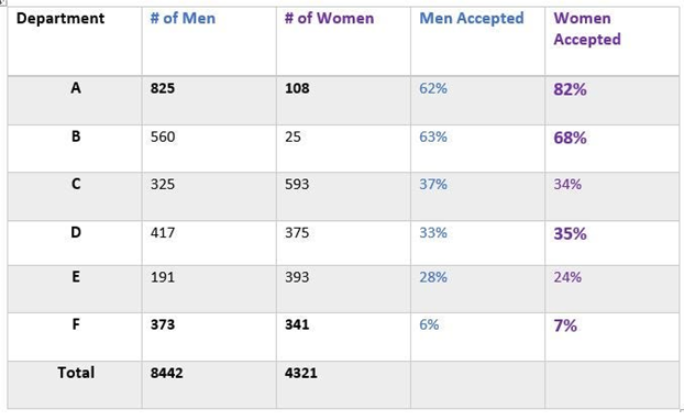

Taking a look at the table source (https://medium.com/@dexter.shawn/how-uc-berkeley-almost-got-sued-because-of-lying-data-aaa5d641f571) may help you in your decisions upon completing this task. 

You may use any software (except for ChatGTP and other AI tools). Desribe what you changed and why.

In [ ]:
# Insert table here

from IPython.display import display, HTML

data = {
    'Department': ['A', 'B', 'C', 'D', 'E', 'F'],
    'Men Applicants': [825, 560, 325, 417, 191, 373],
    'Women Applicants': [108, 25, 593, 375, 393, 341],
    'Men Admitted': [512, 353, 120, 138, 53, 22],
    'Women Admitted': [89, 17, 202, 131, 94, 24],
    'Men Accept %': [62, 63, 37, 33, 28, 6],
    'Women Accept %': [82, 68, 34, 35, 24, 7]
}

df = pd.DataFrame(data)

total_row = pd.DataFrame({
    'Department': ['Total'],
    'Men Applicants': [df['Men Applicants'].sum()],
    'Women Applicants': [df['Women Applicants'].sum()],
    'Men Admitted': [df['Men Admitted'].sum()],
    'Women Admitted': [df['Women Admitted'].sum()],
    'Men Accept %': [int((df['Men Admitted'].sum() / df['Men Applicants'].sum()) * 100)],
    'Women Accept %': [int((df['Women Admitted'].sum() / df['Women Applicants'].sum()) * 100)]
})

df_complete = pd.concat([df, total_row], ignore_index=True)

styled_df = (df_complete.style
    .set_properties(**{
        'text-align': 'right',
        'font-size': '12pt',
        'padding': '10px 12px',
        'border-bottom': '1px solid #e0e0e0',
        'font-family': 'Arial, sans-serif',
        'background-color': 'white',
        'color': 'black'
    })
    .set_properties(subset=['Department'], **{
        'text-align': 'left',
        'font-weight': '600'
    })
    .set_table_styles([
        {'selector': 'thead th', 
         'props': [
             ('background-color', '#f8f9fa'),
             ('font-weight', '700'),
             ('text-align', 'right'),
             ('border-bottom', '2px solid #333'),
             ('padding', '12px'),
             ('color', '#333'),
             ('font-size', '12pt')
         ]},
        {'selector': 'thead th:first-child',
         'props': [('text-align', 'left')]},
        {'selector': 'tbody tr:last-child',
         'props': [
             ('border-top', '2px solid #333'),
             ('font-weight', '700'),
             ('background-color', '#f8f9fa')
         ]},
        {'selector': '',
         'props': [
             ('border-collapse', 'collapse'),
             ('border', 'none'),
             ('background-color', 'white')
         ]},
        {'selector': 'tbody',
         'props': [('background-color', 'white')]},
        {'selector': 'tbody td',
         'props': [('background-color', 'white')]}
    ])
    .hide(axis='index')
    .format({
        'Men Applicants': '{:,}',
        'Women Applicants': '{:,}',
        'Men Admitted': '{:,}',
        'Women Admitted': '{:,}'
    })
)

print("Table 1. UC Berkeley Graduate Admissions by Department and Gender\n")
display(styled_df)

Table 1. UC Berkeley Graduate Admissions by Department and Gender



Department,Men Applicants,Women Applicants,Men Admitted,Women Admitted,Men Accept %,Women Accept %
A,825,108,512,89,62,82
B,560,25,353,17,63,68
C,325,593,120,202,37,34
D,417,375,138,131,33,35
E,191,393,53,94,28,24
F,373,341,22,24,6,7
Total,"2,691","1,835","1,198",557,44,30


In [ ]:
#Only using pandas to create the table

data = {
    'Department': ['A', 'B', 'C', 'D', 'E', 'F', ''],
    'Men Applicants': [825, 560, 325, 417, 191, 373, ''],
    'Women Applicants': [108, 25, 593, 375, 393, 341, ''],
    'Men Admitted': [512, 353, 120, 138, 53, 22, ''],
    'Women Admitted': [89, 17, 202, 131, 94, 24, ''],
    'Men Accept %': [62, 63, 37, 33, 28, 6, ''],
    'Women Accept %': [82, 68, 34, 35, 24, 7, '']
}

total_men_app = 825 + 560 + 325 + 417 + 191 + 373
total_women_app = 108 + 25 + 593 + 375 + 393 + 341
total_men_adm = 512 + 353 + 120 + 138 + 53 + 22
total_women_adm = 89 + 17 + 202 + 131 + 94 + 24
total_men_rate = int((total_men_adm / total_men_app) * 100)
total_women_rate = int((total_women_adm / total_women_app) * 100)

data['Department'][-1] = 'Total'
data['Men Applicants'][-1] = total_men_app
data['Women Applicants'][-1] = total_women_app
data['Men Admitted'][-1] = total_men_adm
data['Women Admitted'][-1] = total_women_adm
data['Men Accept %'][-1] = total_men_rate
data['Women Accept %'][-1] = total_women_rate

df = pd.DataFrame(data)

print("\nTable 1. UC Berkeley Graduate Admissions by Department and Gender")
print("=" * 85)
print(df.to_string(index=False))
print("=" * 85)


Table 1. UC Berkeley Graduate Admissions by Department and Gender
Department  Men Applicants  Women Applicants  Men Admitted  Women Admitted  Men Accept %  Women Accept %
         A             825               108           512              89            62              82
         B             560                25           353              17            63              68
         C             325               593           120             202            37              34
         D             417               375           138             131            33              35
         E             191               393            53              94            28              24
         F             373               341            22              24             6               7
     Total            2691              1835          1198             557            44              30


_Insert answer here_

**Styled Table Approach**

Used IPython.display with CSS styling to implement table design principles:

Key improvements:
- Separated headers with gray background and bottom border
- Right-aligned numbers, left-aligned text
- Subtle 1px dividers instead of heavy gridlines
- No unit repetition ("%" only in headers)
- Highlighted totals row with top border
- Added missing data: actual admission numbers and total rates
- Proper spacing and typography for readability

**Simple Pandas Alternative**

Provided .to_string() version for text-based output when HTML rendering isn't available.